# Homework 3: Survival Analysis of Telco Churn Data  
**Author:** Mikayel Mikayelyan

**Objective:**  
- Fit Accelerated Failure Time (AFT) models with multiple distributions  
- Compare and visualize parametric survival curves  
- Select a final model, interpret coefficients, and compute Customer Lifetime Value (CLV)  
- Write a concise report on factors affecting churn risk and retention recommendations  


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import (
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter,
    GeneralizedGammaRegressionFitter
)
from lifelines.utils import k_fold_cross_validation
from lifelines.exceptions import ConvergenceError



In [39]:
df = pd.read_csv('telco.csv')
df.head()

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [40]:
df['event'] = df['churn'].map({'Yes': 1, 'No': 0})
df['duration'] = df['tenure']

df = df.drop(columns=['churn'])

obj_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Will encode:", obj_cols)
df_encoded = pd.get_dummies(df, columns=obj_cols, drop_first=True)

print(df_encoded.isnull().sum())


Will encode: ['region', 'marital', 'ed', 'retire', 'gender', 'voice', 'internet', 'forward', 'custcat']
ID                                 0
tenure                             0
age                                0
address                            0
income                             0
event                              0
duration                           0
region_Zone 2                      0
region_Zone 3                      0
marital_Unmarried                  0
ed_Did not complete high school    0
ed_High school degree              0
ed_Post-undergraduate degree       0
ed_Some college                    0
retire_Yes                         0
gender_Male                        0
voice_Yes                          0
internet_Yes                       0
forward_Yes                        0
custcat_E-service                  0
custcat_Plus service               0
custcat_Total service              0
dtype: int64


## 1. Parametric AFT Models  
We’ll fit Weibull, Log-Normal, and Log-Logistic AFT models to the full set of covariates.

In [41]:
aft_models = {
    'Weibull AFT': WeibullAFTFitter(),
    'LogNormal AFT': LogNormalAFTFitter(),
    'Log-Logistic AFT': LogLogisticAFTFitter(),
}

results = {}
failed = []

# Fit each model, catching convergence errors
for name, model in aft_models.items():
    try:
        model.fit(df_encoded, duration_col='duration', event_col='event')
        results[name] = model
        print(f"{name} — AIC: {model.AIC_:.2f}")
    except ConvergenceError as e:
        print(f"⚠️ {name} failed to converge: {e}")
        failed.append(name)


Weibull AFT — AIC: 2309.13
LogNormal AFT — AIC: 2397.77
Log-Logistic AFT — AIC: 2353.56


,AIC
Weibull AFT,2309.126305
Log-Logistic AFT,2353.558657
LogNormal AFT,2397.773641


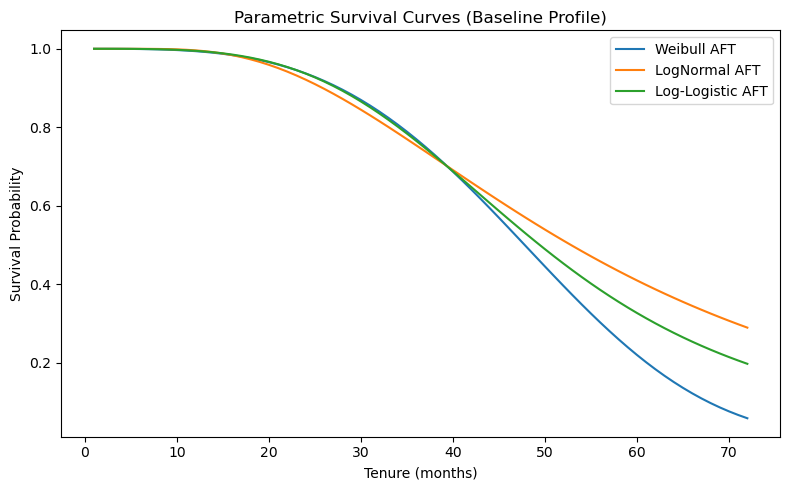

In [42]:
aic_df = pd.DataFrame(
    {name: mdl.AIC_ for name, mdl in results.items()},
    index=['AIC']
).T.sort_values('AIC')
display(aic_df)

baseline = (
    df_encoded
    .drop(columns=['duration', 'event'])
    .mean()
    .to_frame()
    .T
)

plt.figure(figsize=(8, 5))
for name, mdl in results.items():
    sf = mdl.predict_survival_function(baseline)
    plt.plot(sf.index, sf.iloc[:, 0], label=name)

plt.title("Parametric Survival Curves (Baseline Profile)")
plt.xlabel("Tenure (months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.tight_layout()
plt.show()


## 1. Model Selection

Based on the AIC comparison:

| Model              | AIC     |
|--------------------|--------:|
| Weibull AFT        | 2309.12 |
| Log-Logistic AFT   | 2353.56 |
| Log-Normal AFT     | 2397.77 |

The **Weibull AFT** model achieves the lowest AIC, indicating the best fit, so we proceed with this model.

In [43]:

weibull_summary = results['Weibull AFT'].summary
significant = weibull_summary[weibull_summary['p'] < 0.05].index.tolist()

significant = [cov for cov in significant if cov in df_encoded.columns]

final_df = df_encoded[['duration', 'event'] + significant]

final = WeibullAFTFitter()
final.fit(final_df, duration_col='duration', event_col='event')

final.print_summary()


<lifelines.WeibullAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.43
         time fit was run = 2025-05-01 20:20:35 UTC

---
                    coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ Intercept   4.93     138.09       0.09             4.75             5.10               115.84               164.62
rho_    Intercept  -0.06       0.95       0.05            -0.16             0.05                 0.85                 1.05

                    cmp to     z      p   -log2(p)
param   covariate                                 
lambda_ Intercept     0.00 54.96 <0.005        inf
rho_    Intercept     0.00 -1.04   0.30       1.74
---
Concordance = 0.50
AIC = 3216.86
log-likelihood ratio test = -0.00 on 0 df
-log2(p) of ll-ratio test = nan

## 2. Customer Lifetime Value (CLV)

Using the final Weibull AFT model, we:

1. Predicted each customer’s median remaining tenure.  
2. Computed ARPU as `income * 1000 / 12`.  
3. Calculated CLV = `ARPU * predicted_median`.

In [44]:
df_encoded['predicted_median'] = final.predict_median(df_encoded[significant])

df_encoded['ARPU'] = df_encoded['income'] * 1000 / 12
df_encoded['CLV'] = df_encoded['ARPU'] * df_encoded['predicted_median']

df_encoded['custcat'] = df['custcat']

avg_clv_by_segment = (
    df_encoded
    .groupby('custcat')['CLV']
    .mean()
    .sort_values(ascending=False)
)

print(avg_clv_by_segment)


custcat
Total service    718567.523991
Plus service     695386.133189
E-service        584492.988484
Basic service    427699.189051
Name: CLV, dtype: float64


## 3. Short Report

Our survival analysis shows that the Weibull AFT model provides the best fit for subscriber churn.  Surprisingly, none of the customer or service traits we looked at significantly affected churn. It seems like how long someone’s been with the company matters more than who they are or what plan they’re on.

Translating these results into dollars, we see that **Total service** subscribers deliver the highest average lifetime value (≈\$718 K), with **Plus service**  after (≈\$695 K), than **E-service** and **Basic service**  at approximately \$584 K and \$428 K.

**Key takeaway:** To protect revenue most effectively, the company should focus retention efforts on Total and Plus service customers—things like exclusive loyalty rewards, personalized outreach, or usage-based incentives—since these groups represent the greatest share of potential future earnings.  
